#Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

Carregamento dos Dados e Visualização Inicial

Primeiras linhas do dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

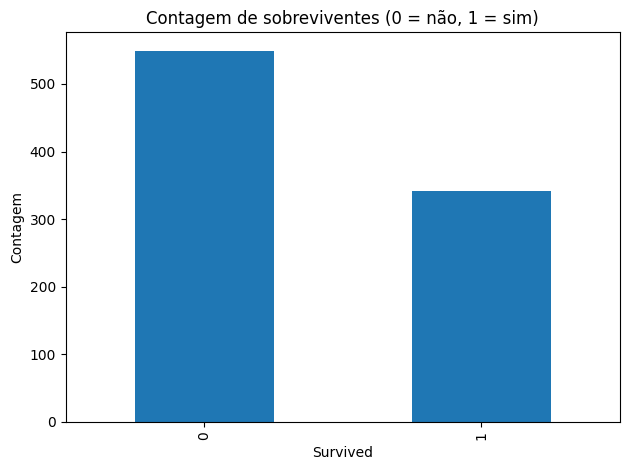

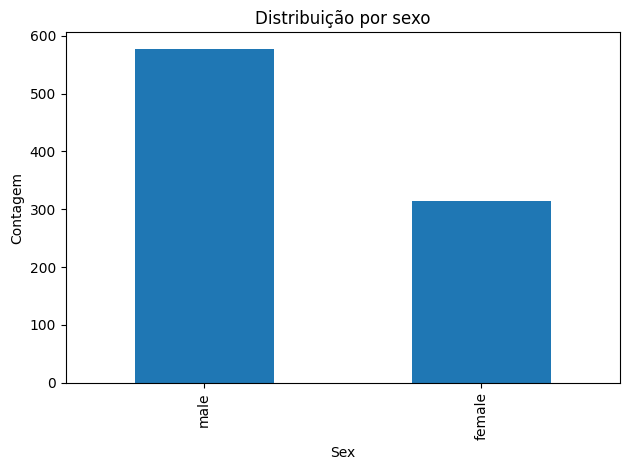

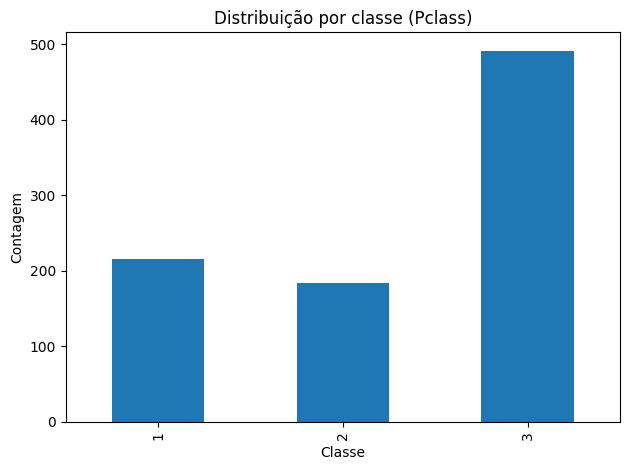

In [2]:
data_path = "titanic-dataset.csv"
df = pd.read_csv(data_path)

print("Primeiras linhas do dataset:")
print(df.head(), "\n")

print("Informações gerais:")
print(df.info(), "\n")

print("Estatísticas descritivas (variáveis numéricas):")
print(df.describe(include="number"), "\n")

print("Distribuição da variável alvo (Survived):")
print(df["Survived"].value_counts(normalize=True))

plt.figure()
df["Survived"].value_counts().plot(kind="bar")
plt.title("Contagem de sobreviventes (0 = não, 1 = sim)")
plt.xlabel("Survived")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()

plt.figure()
df["Sex"].value_counts().plot(kind="bar")
plt.title("Distribuição por sexo")
plt.xlabel("Sex")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()

plt.figure()
df["Pclass"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição por classe (Pclass)")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()


# Pré-processamento dos dados

In [3]:
cols_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target_col = "Survived"

df_model = df[cols_features + [target_col]].copy()

df_model["Age"].fillna(df_model["Age"].median(), inplace=True)
df_model["Fare"].fillna(df_model["Fare"].median(), inplace=True)


df_model["Embarked"].fillna(df_model["Embarked"].mode()[0], inplace=True)


df_model["Sex"] = df_model["Sex"].map({"male": 0, "female": 1})

df_model = pd.get_dummies(df_model, columns=["Embarked"], drop_first=True)

print("\nColunas após o pré-processamento:")
print(df_model.columns)

X = df_model.drop(columns=[target_col])
y = df_model[target_col]


Colunas após o pré-processamento:
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


/tmp/ipython-input-3873542486.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model["Age"].fillna(df_model["Age"].median(), inplace=True)
/tmp/ipython-input-3873542486.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

# Divisão Teste e Treino

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantém proporção de classes
)

print("\nTamanho dos conjuntos:")
print("Treino:", X_train.shape)
print("Teste :", X_test.shape)


Tamanho dos conjuntos:
Treino: (712, 8)
Teste : (179, 8)


# Normalização Pós-split

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinamento do KNN

In [6]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

# Avaliação do Modelo


Acurácia do KNN (k=5): 0.8156

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179

Matriz de confusão:
[[98 12]
 [21 48]]


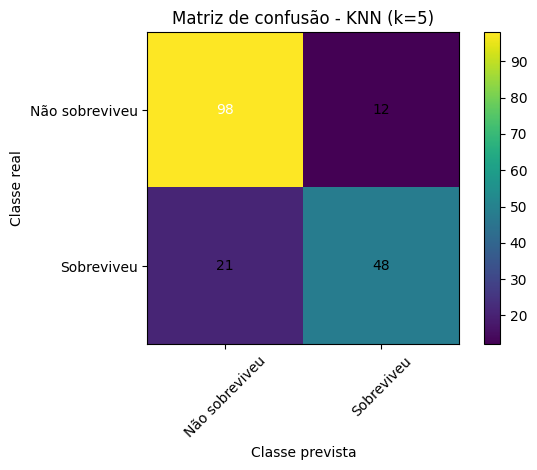

In [7]:
y_pred = knn.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"\nAcurácia do KNN (k={k}): {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:")
print(cm)

# Plot da matriz de confusão
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title(f"Matriz de confusão - KNN (k={k})")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Não sobreviveu", "Sobreviveu"], rotation=45)
plt.yticks(tick_marks, ["Não sobreviveu", "Sobreviveu"])

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

plt.ylabel("Classe real")
plt.xlabel("Classe prevista")
plt.tight_layout()
plt.show()